# Error Analysis

Notebook này dùng output từ `src/train_baseline.ipynb` và `src/evaluate.ipynb` để phân tích lỗi:

- So sánh metrics giữa các model.
- Chọn model tốt nhất theo Macro-F1.
- Xem các cặp MITRE technique bị nhầm nhiều nhất.
- Vẽ confusion matrix cho nhóm label xuất hiện nhiều nhất.
- Hiển thị các dòng dự đoán sai để phục vụ phân tích lỗi.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
EVALUATION_DIR = Path("../results/evaluation")
METRICS_SUMMARY_PATH = EVALUATION_DIR / "metrics_summary.csv"

if not METRICS_SUMMARY_PATH.exists():
    raise FileNotFoundError("Chưa có metrics_summary.csv. Hãy chạy src/train_baseline.ipynb rồi src/evaluate.ipynb trước.")

metrics_summary = pd.read_csv(METRICS_SUMMARY_PATH).sort_values("macro_f1", ascending=False)
metrics_summary

,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,model,test_samples,num_labels
0,0.496392,0.364027,0.365065,0.393393,0.485601,0.497788,0.496392,linear_svc,2633,154
1,0.391948,0.309539,0.324122,0.376059,0.387314,0.490207,0.391948,logistic_regression,2633,154
2,0.424991,0.263771,0.343012,0.261170,0.381578,0.425266,0.424991,random_forest,2633,154
3,0.245727,0.031416,0.069758,0.039316,0.157106,0.239547,0.245727,multinomial_nb,2633,154
4,0.033802,0.017794,0.019373,0.024591,0.038134,0.056636,0.033802,lightgbm,2633,154


## 1. Chọn model tốt nhất theo Macro-F1

In [3]:
BEST_MODEL = metrics_summary.iloc[0]["model"]
BEST_MODEL_DIR = EVALUATION_DIR / BEST_MODEL

print(f"Best model: {BEST_MODEL}")
display(metrics_summary)

Best model: linear_svc


,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,model,test_samples,num_labels
0,0.496392,0.364027,0.365065,0.393393,0.485601,0.497788,0.496392,linear_svc,2633,154
1,0.391948,0.309539,0.324122,0.376059,0.387314,0.490207,0.391948,logistic_regression,2633,154
2,0.424991,0.263771,0.343012,0.261170,0.381578,0.425266,0.424991,random_forest,2633,154
3,0.245727,0.031416,0.069758,0.039316,0.157106,0.239547,0.245727,multinomial_nb,2633,154
4,0.033802,0.017794,0.019373,0.024591,0.038134,0.056636,0.033802,lightgbm,2633,154


## 2. Các cặp label bị nhầm nhiều nhất

In [4]:
misclassified = pd.read_csv(BEST_MODEL_DIR / "misclassification_summary.csv")
display(misclassified.head(30))

,true_label,predicted_label,error_count
0,T1203,T1059,12
1,T1595,T1203,8
2,T1204,T1566,8
3,T1557,T1566,8
4,T1203,T1068,7
5,T1565,T1606,7
6,T1059,T1027,7
7,T1059,T1204,6
8,T1059,T1195,6
9,T1554,T1195,5


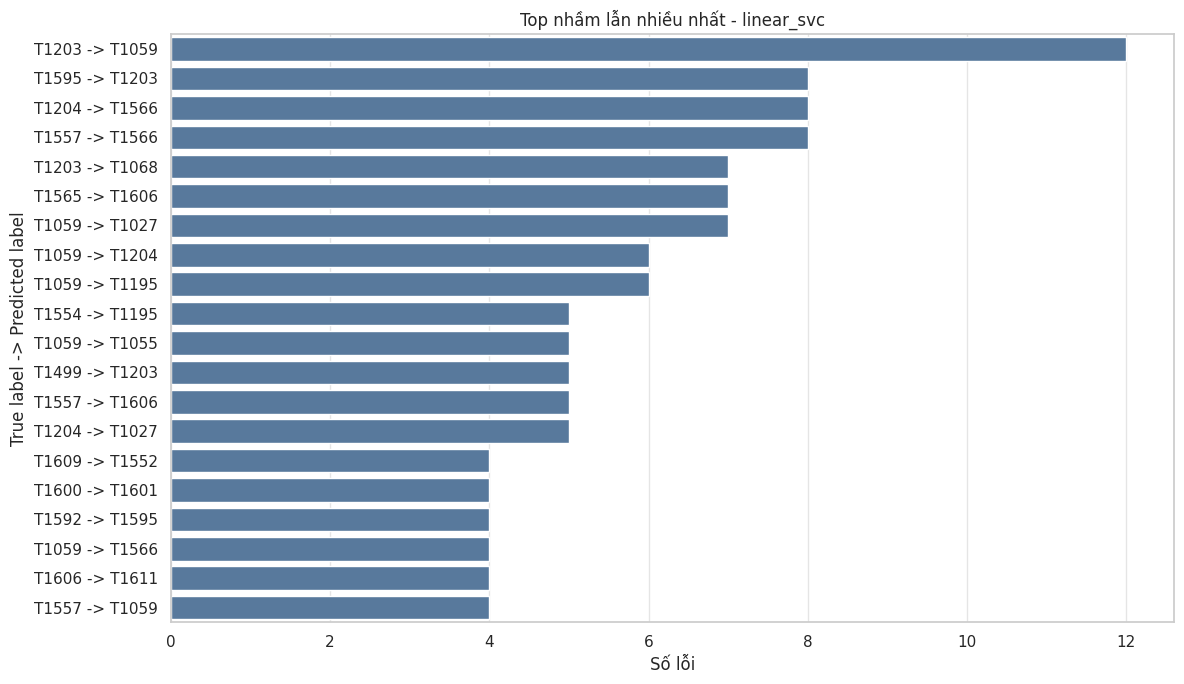

In [5]:
top_errors = misclassified.head(20).copy()
if not top_errors.empty:
    top_errors["pair"] = top_errors["true_label"] + " -> " + top_errors["predicted_label"]
    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_errors, y="pair", x="error_count", color="#4C78A8")
    plt.title(f"Top nhầm lẫn nhiều nhất - {BEST_MODEL}")
    plt.xlabel("Số lỗi")
    plt.ylabel("True label -> Predicted label")
    plt.tight_layout()
    plt.show()

## 3. Confusion matrix

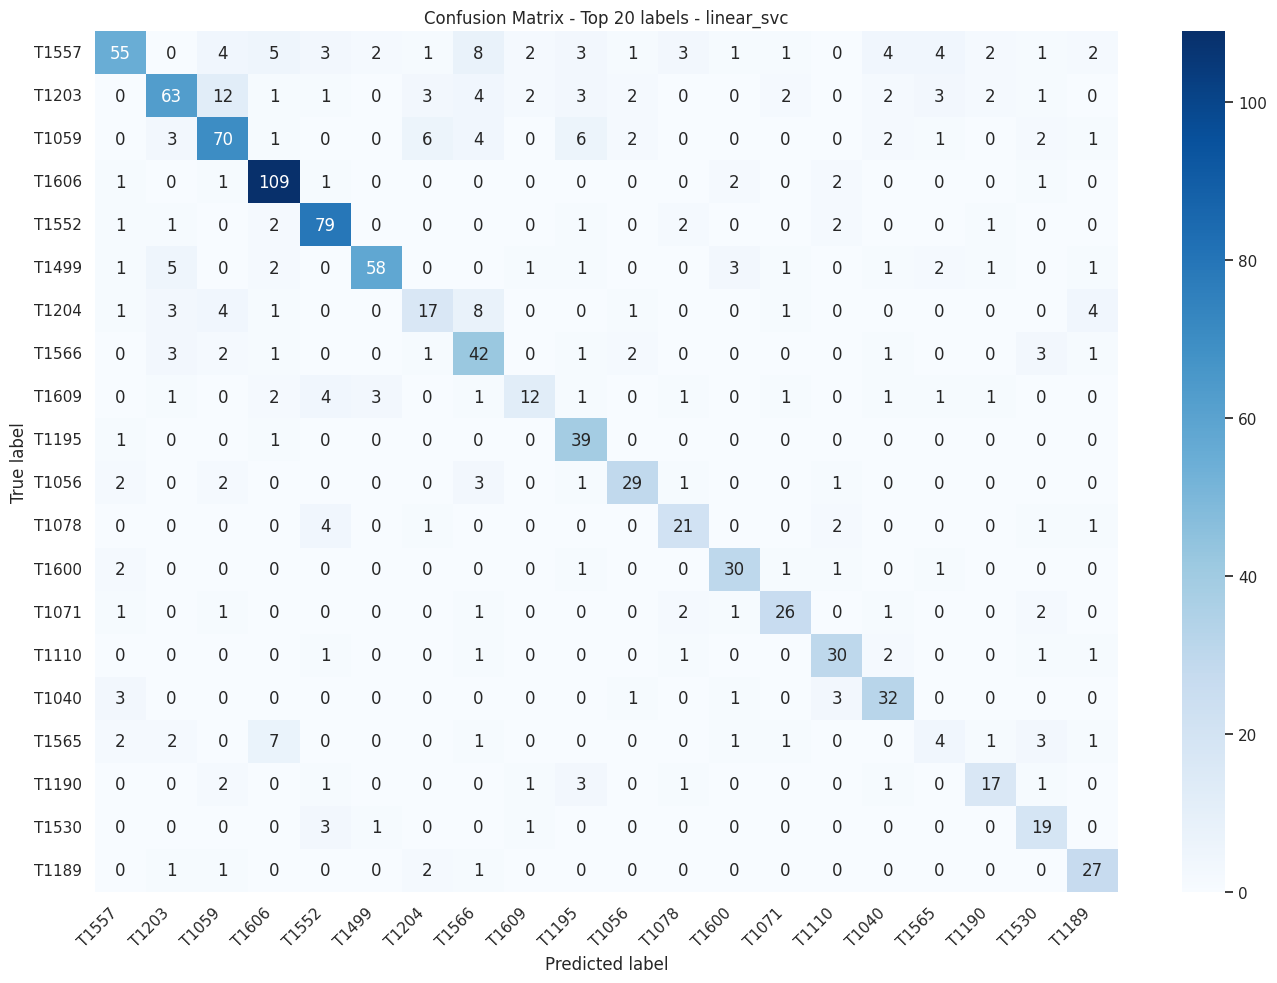

In [6]:
cm = pd.read_csv(BEST_MODEL_DIR / "confusion_matrix.csv", index_col=0)

TOP_N_LABELS = 20
top_labels = cm.sum(axis=1).sort_values(ascending=False).head(TOP_N_LABELS).index
cm_top = cm.loc[top_labels, top_labels]

plt.figure(figsize=(14, 10))
sns.heatmap(cm_top, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Top {TOP_N_LABELS} labels - {BEST_MODEL}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Xem từng dòng dự đoán sai

In [7]:
error_analysis = pd.read_csv(BEST_MODEL_DIR / "error_analysis.csv")
errors_only = error_analysis[error_analysis["is_error"]].copy()

print(f"Tổng dòng test: {len(error_analysis):,}")
print(f"Số dòng dự đoán sai: {len(errors_only):,}")
display(errors_only.head(30))

Tổng dòng test: 2,633
Số dòng dự đoán sai: 1,326


,text,true_label,predicted_label,is_error
0,Abusing CI/CD Webhook for Lateral Access to On...,T1190,T1195,True
1,Multi-Device BlueBorne Attack Lab Simulation. ...,T1203,T1071,True
2,Internal Redis Enumeration via Container Scan....,T1046,T1210,True
6,Hijacking Smart Sprinkler System Over Cloud. A...,T1078,T0810,True
8,Hijack via Deletion-Race in CI/CD Deployment. ...,T1609,T1583,True
12,"Tool Output Reflection. A tool (e.g., PDF pars...",T1557,T1087,True
15,Fake Antivirus UI to Lure Trust. Insider creat...,T1036,T1546,True
16,Registry MRU Artifacts Trace Execution of Hidd...,T1003,T1546,True
17,Compromising Binaries via Homebrew Tap Injecti...,T1548,T1204,True
18,Tampered GSDML File for Industrial Protocol Hi...,T1195,T0859,True


## 5. Lọc lỗi theo label cụ thể

In [9]:
# Đổi giá trị này nếu muốn xem lỗi của một technique cụ thể, ví dụ: TARGET_LABEL = "T1190"
TARGET_LABEL = "T1190"

if TARGET_LABEL:
    display(errors_only[errors_only["true_label"] == TARGET_LABEL].head(50))
else:
    print("Đặt TARGET_LABEL để lọc lỗi theo một MITRE technique cụ thể.")

,text,true_label,predicted_label,is_error
0,Abusing CI/CD Webhook for Lateral Access to On...,T1190,T1195,True
319,Open S3 Bucket Hosting Agent Tools. Developers...,T1190,T1530,True
370,Metadata API Theft via SSRF in Internal Dev AP...,T1190,T1552,True
607,Mass Assignment Vulnerabilities in REST APIs. ...,T1190,T1214,True
700,Unauthorized Printing via Open Wi-Fi Printer. ...,T1190,T1040,True
701,Remote URL Execution via LLM Output. LLM outpu...,T1190,T1059,True
927,"Exposed Databases (MongoDB, MySQL). Database p...",T1190,T1210,True
964,Long-Term APT Access via Satellite Tracking Ap...,T1190,T1078,True
1008,Insecure Dependencies Go Unnoticed Due to Brok...,T1190,T1195,True
1009,Misconfigured SCA Tool Allows Merging Known CV...,T1190,T1195,True
